The purpose of this notebook is to calculate how the irregular sampling of the timeseries of interest affect the power spectrum estimate. A second goal is to understand why very red signals converge to the spectral window with the same power.

In [1]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path
from astropy.timeseries import LombScargle
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs, calculate_mean_and_ci
from methane_noise_forcing.core import sample_ensemble_series, FirnFilter
from methane_noise_forcing.noise import (
    simulate_white_noise_ar1,
    calculate_white_noise_ar1_params,
)
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
    large_font,
)

plt.rcParams.update(matplotlib_rcparams)
# plt.rcParams["figure.dpi"] = 200

In [2]:
psd_x_tick_labels = [1000, 100, 20, 5, 1]

In [3]:
## load all obs
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(config_name="config")

site_names = ["wdc05a", "wdc06a", "gisp2", "neem"]

## import data and power spectra
data = {}
power_spectra = {}
for site in site_names:
    data[site] = io.load_observational_data(site, **cfg.io[site].input)

    power_spectra[site] = xr.open_dataset(cfg.io[site].power_spectra_path)

2025-11-11 17:38:15,225 - methane_noise_forcing.io - INFO - Loading WDC05A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc05a.csv
2025-11-11 17:38:15,514 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-11-11 17:38:15,533 - methane_noise_forcing.io - INFO - Loading GISP2 data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_gisp2.csv
2025-11-11 17:38:15,548 - methane_noise_forcing.io - INFO - Loading NEEM data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/rhodesandbrook2019_neem.tab


# spectral window

## expected solution
The spectral window is given by the Fourier transform of the sampling function. For a set of sampling times \( t_i \), the sampling function can be represented as:
$
\begin{equation}
W(f) = \frac{1}{N} \left| \sum_{i=1}^{N} e^{-2 \pi i f t_i} \right|^2 
\end{equation}
$

In [4]:
def calc_spectral_window(times, freq, t0=None):
    """
    Return normalized spectral window |Σ exp(-2πi f (t - t0))|^2 / N^2.
    
    Parameters
    ----------
    times : array-like
        Sampling times.
    freq : array-like
        Frequencies at which to evaluate the spectral window.
    t0 : float, optional
        Reference time to center the phases. If None, uses min(times).
    """
    t = np.asarray(times, float)
    f = np.asarray(freq, float)
    if t0 is None:
        t0 = t.min()
    phase = np.exp(-2j * np.pi * f[:, None] * (t[None, :] - t0))
    W = np.abs(phase.sum(axis=1))**2 / (t.size**2)
    return W

In [5]:
period_eval_min = 1
period_eval_max = 1000
freq_eval = np.logspace(
    np.log10(1/period_eval_max), 
    np.log10(1/period_eval_min), 
    1000
)  # frequencies to evaluate spectral window

spectral_windows = {}
spectral_windows_smoothed = {}
for site in site_names:
    times = data[site]["gas_age"].values
    spectral_windows[site] = calc_spectral_window(times, freq_eval)
    # smooth spectral window with a moving average filter
    window_size = 20
    spectral_windows_smoothed[site] = np.convolve(
        spectral_windows[site], 
        np.ones(window_size)/window_size, 
        mode='same'
    )

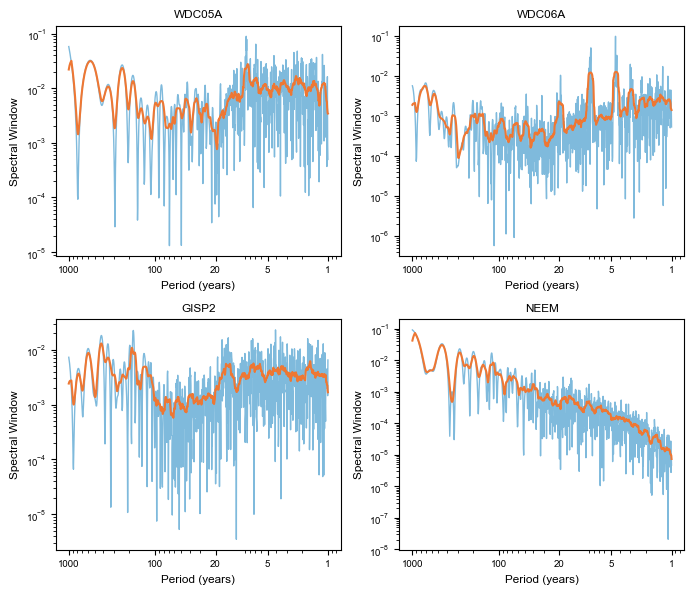

In [6]:
# plot empirical spectral windows
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(fig_width_options["two_column_large"], 6), tight_layout=True
)
axs = axs.flatten()

for i, site in enumerate(site_names):
    ax = axs[i]
    ax.plot(
        1 / freq_eval,
        spectral_windows[site],
        color=colors_vibrant["blue"],
        lw=1,
        alpha=0.5,
    )
    ax.plot(
        1 / freq_eval,
        spectral_windows_smoothed[site],
        color=colors_vibrant["orange"],
        # lw=2,
        # alpha=0.5,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Period (years)", fontsize=large_font)
    ax.set_ylabel("Spectral Window", fontsize=large_font)
    ax.set_title(site.upper(), fontsize=large_font)
    ax.set_xticks(psd_x_tick_labels)
    ax.set_xticklabels([f"{tick}" for tick in psd_x_tick_labels])
    ax.grid(False)

# Spectral leakage
At very slow timescales, the power spectrum of the sampled signal converges to the spectral window. This is because, at these timescales, the signal's variations are much slower than the sampling intervals (leakage), leading to a situation where the sampled signal effectively captures the characteristics of the sampling function itself. As a result, the power spectrum reflects the distribution of the sampling times rather than the intrinsic properties of the signal.

It's still kind of confusing to me - I'm not exactly sure why this does not happen with the continuous signal.

I'm going to generate a bunch of AR(1)s, sample them, and plot their continuous and sampled power spectra to see this effect in action.

In [7]:
## generate ensemble
timescales = [0, 1, 10, 100, 1000, 10000] # AR(1) timescales to simulate, 0 is white noise
variance = 100
dt = 1 # time step in years
n_years = 5000
n_ens = 100
noise = {}
for tau in timescales[1:]:
    params = calculate_white_noise_ar1_params(tau, dt, variance)
    red_noise, white_noise = simulate_white_noise_ar1(
        phi=params.phi,
        sigma_eps=params.sigma_eps,
        n_steps=int(n_years / dt),
        n_ens=n_ens,
    )
    # create dataarray
    noise[tau] = xr.DataArray(
        red_noise[:, :, np.newaxis],
        dims=["ensemble", "time", "timescale"],
        coords={
            "ensemble": np.arange(n_ens),
            "time": np.arange(0, n_years, dt),
            "timescale": [tau],
        },
    )
noise[0] = xr.DataArray(
    white_noise[:, :, np.newaxis],
    dims=["ensemble", "time", "timescale"],
    coords={
        "ensemble": np.arange(n_ens),
        "time": np.arange(0, n_years, dt),
        "timescale": [0],
    },
)
noise = xr.concat([noise[tau] for tau in timescales], dim="timescale")

In [8]:
## sample ensemble at observed times
site = "wdc06a"
core_time = data[site]["gas_age"].values
noise_sampled = {}
for tau in timescales:
    noise_sampled[tau] = sample_ensemble_series(
        da=noise.sel(timescale=tau),
        core_time=core_time,
        core_offset_flag="start",
        series_offset=0,
    ).expand_dims(dim="timescale").assign_coords(timescale=[tau])
noise_sampled = xr.concat([noise_sampled[tau] for tau in timescales], dim="timescale")

In [9]:
## change noise to same intervals as noise samples
len_sample = noise_sampled.time[0] - noise_sampled.time[-1]
mask = noise.time <= len_sample
noise_continuous = noise.sel(time=mask)

In [10]:
## ensure equal variance in all ensemble members
var_noise_sampled = noise_sampled.var(dim="time")
var_noise_continuous = noise_continuous.var(dim="time")

# re-scale to target variance
noise_sampled = noise_sampled * np.sqrt(variance / var_noise_sampled)
noise_continuous = noise_continuous * np.sqrt(variance / var_noise_continuous)

In [11]:
## use lomb-scargle to calculate power spectra of continuous and sampled signals
def calculate_psd(da, time):
    frequencies, power_spectrum = LombScargle(time.values, da.values).autopower(
        normalization="psd",
        samples_per_peak=1,
    )
    return frequencies, power_spectrum

psd_continuous = {}
psd_sampled = {}
for tau in timescales:
    psd_continuous[tau] = []
    psd_sampled[tau] = []
    for ens in range(n_ens):
        # continuous
        frequencies_cont, power_cont = calculate_psd(
            noise_continuous.sel(ensemble=ens, timescale=tau), 
            noise_continuous.time
        )
        psd_continuous[tau].append(power_cont)
        # sampled
        frequencies_samp, power_samp = calculate_psd(
            noise_sampled.sel(ensemble=ens, timescale=tau),
            noise_sampled.time
        )
        psd_sampled[tau].append(power_samp)
    ## combine into dataarrays
    psd_continuous[tau] = xr.DataArray(
        np.array(psd_continuous[tau]),
        dims=["ensemble", "frequency"],
        coords={
            "ensemble": np.arange(n_ens),
            "frequency": frequencies_cont,
        },
    )
    psd_sampled[tau] = xr.DataArray(
        np.array(psd_sampled[tau]),
        dims=["ensemble", "frequency"],
        coords={
            "ensemble": np.arange(n_ens),
            "frequency": frequencies_samp,
        },
    )

Text(0.5, 0.01, 'Period (years)')

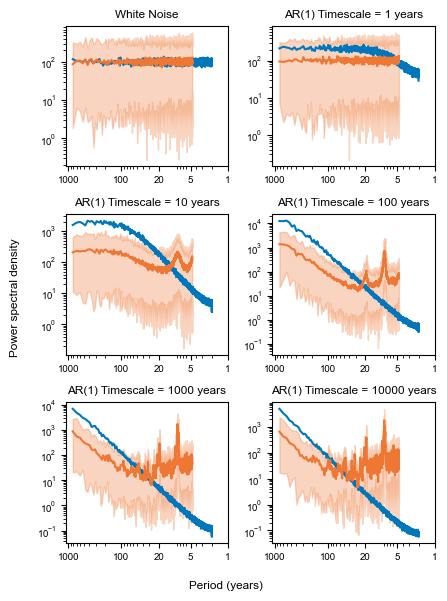

In [12]:
## make n-by-2 plots of continuous vs sampled power spectra for each timescale
freq_min = 1/1000 # inverse years
n_cols = 2
n_rows = int(np.ceil(len(timescales) / n_cols))
fig, axs = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(fig_width_options["two_column_small"], 2 * n_rows),
    tight_layout=True,
)
axs = axs.flatten()
for i, tau in enumerate(timescales):
    ax = axs[i]
    # continuous
    mean_cont, ci_lower_cont, ci_upper_cont = calculate_mean_and_ci(
        psd_continuous[tau].sel(frequency=slice(freq_min, 1/2/dt)), ci=0.95
    )
    ax.plot(
        1 / psd_continuous[tau].sel(frequency=slice(freq_min, 1/2/dt)).frequency,
        mean_cont,
        color=colors_vibrant["blue"],
        label="Continuous",
    )
    # sampled
    mean_samp, ci_lower_samp, ci_upper_samp = calculate_mean_and_ci(
        psd_sampled[tau].sel(frequency=slice(freq_min, None)), ci=0.95
    )
    ax.plot(
        1 / psd_sampled[tau].sel(frequency=slice(freq_min, None)).frequency,
        mean_samp,
        color=colors_vibrant["orange"],
        label="Sampled",
    )
    ax.fill_between(
        1 / psd_sampled[tau].sel(frequency=slice(freq_min, None)).frequency,
        ci_lower_samp,
        ci_upper_samp,
        color=colors_vibrant["orange"],
        alpha=0.3,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    if tau != 0:
        ax.set_title(f"AR(1) Timescale = {tau} years", fontsize=large_font)
    else:
        ax.set_title(f"White Noise", fontsize=large_font)
    ax.set_xticks(psd_x_tick_labels)
    ax.set_xticklabels([f"{tick}" for tick in psd_x_tick_labels])
    ax.grid(False)
if len(timescales) % 2 != 0:
    axs[-1].axis('off')
    # axs[-2].legend()
# else:
#     # axs[-1].legend()
fig.supylabel("Power spectral density", fontsize=large_font)
fig.supxlabel("Period (years)", fontsize=large_font)

Text(0.5, 0, 'Period (years)')

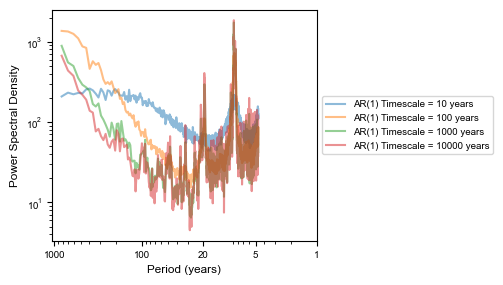

In [13]:
## plot the 10-10,000 year sampled mean psd
fig, ax = plt.subplots(
    1, 1, figsize=(fig_width_options["one_column"], 3)
)
for tau in [10, 100, 1000, 10000]:
    mean_samp, ci_lower_samp, ci_upper_samp = calculate_mean_and_ci(
        psd_sampled[tau].sel(frequency=slice(freq_min, None)), ci=0.95
    )
    ax.plot(
        1 / psd_sampled[tau].sel(frequency=slice(freq_min, None)).frequency,
        mean_samp,
        label=f"AR(1) Timescale = {tau} years" if tau !=0 else "White Noise",
        alpha=0.5
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xticks(psd_x_tick_labels)
ax.set_xticklabels([f"{tick}" for tick in psd_x_tick_labels])
ax.set_ylabel("Power Spectral Density", fontsize=large_font)
ax.set_xlabel("Period (years)", fontsize=large_font)

To me, it's pretty apparent that at very long timescales of an AR(1) process, the windowing (boxcar filter due to sampling a finite sequence) is dominating the power spectrum estimate of the sampled series. Therefore, the spectral window dominates, and leakage occurs.

What's more relevant is that the slope of the background spectrum is **not** a reliable measure of the underlying process at these long timescales when sampling is irregular. The slopes of 10-1000 year timescales would be pretty similar for all these processes, despite their different underlying timescales.